# Double DQN — LunarLander-v2

## 1. Konfiguracja

In [1]:
import torch
import random
import numpy as np
import gym
import warnings

SEED = 42
OPTIMIZE_WITH_HARDWARE = True

device = torch.device('cpu')
if OPTIMIZE_WITH_HARDWARE:
    if torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Wybrano urz\u0105dzenie: MPS')
    elif torch.cuda.is_available():
        device = torch.device('cuda')
        print('Wybrano urz\u0105dzenie: GPU z obs\u0142ug\u0105 CUDA')
        print(f'Nazwa urz\u0105dzenia CUDA: {torch.cuda.get_device_name()}')
else:
    print('Wybrano urz\u0105dzenie: CPU')

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

warnings.filterwarnings("ignore")

Wybrano urządzenie: GPU z obsługą CUDA
Nazwa urządzenia CUDA: NVIDIA GeForce RTX 3060 Laptop GPU


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Inicjalizacja środowiska

In [2]:
env = gym.make("LunarLander-v2")
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

state = env.reset()
if isinstance(state, tuple):
    state = state[0]

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    result = env.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
    else:
        next_state, reward, done, info = result
    env.render("human")
    if done:
        break

env.close()

print(f'Ilo\u015b\u0107 mo\u017cliwych akcji: {env.action_space.n}')

Ilość możliwych akcji: 4


## 3. Hiperparametry

In [3]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_START = 1000
TARGET_UPDATE_STEPS = 1000
MAX_EPISODES = 500
MAX_STEPS = 1000
HIDDEN_SIZES = (128, 128)

## 4. Sieć neuronowa

In [4]:
import torch.nn as nn


class DQNetwork(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=HIDDEN_SIZES):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state)

## 5. Agent DQN

In [5]:
from collections import deque


class DQNAgent:
    def __init__(self, input_size, output_size):
        self.output_size = output_size
        self.epsilon = EPSILON_START
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.total_steps = 0
        self.model = DQNetwork(input_size, output_size).to(device)
        self.target_model = DQNetwork(input_size, output_size).to(device)
        self.update_target_model()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=LEARNING_RATE)
        self.loss_function = nn.SmoothL1Loss()

    def update_target_model(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def memorize(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.output_size)
        state = torch.FloatTensor(state).to(device).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.model(state)).item()

    def replay(self):
        if len(self.memory) < TRAIN_START:
            return None
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones, dtype=np.float32)).unsqueeze(1).to(device)

        q_values = self.model(states).gather(1, actions)
        next_actions = self.model(next_states).argmax(1).unsqueeze(1)
        next_q_values = self.target_model(next_states).gather(1, next_actions).detach()
        target_q_values = rewards + GAMMA * next_q_values * (1 - dones)

        loss = self.loss_function(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.total_steps += 1
        if self.total_steps % TARGET_UPDATE_STEPS == 0:
            self.update_target_model()

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

## 6. Trening

In [ ]:
env = gym.make("LunarLander-v2")
env.action_space.seed(SEED)
env.observation_space.seed(SEED)
input_size = env.observation_space.shape[0]
output_size = env.action_space.n
agent = DQNAgent(input_size, output_size)

rewards_history = []
loss_history = []
length_history = []
epsilon_history = []

for episode in range(MAX_EPISODES):
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    total_reward = 0
    done = False
    step = 0
    episode_losses = []

    while not done and step < MAX_STEPS:
        action = agent.act(state)
        result = env.step(action)
        if len(result) == 5:
            next_state, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            next_state, reward, done, info = result

        agent.memorize(state, action, reward, next_state, done)
        total_reward += reward
        state = next_state
        loss = agent.replay()
        if loss is not None:
            episode_losses.append(loss)
        step += 1

    agent.decay_epsilon()
    rewards_history.append(total_reward)
    length_history.append(step)
    epsilon_history.append(agent.epsilon)
    avg_loss = np.mean(episode_losses) if len(episode_losses) > 0 else 0
    loss_history.append(avg_loss)
    print(f"Epizod {episode + 1}/{MAX_EPISODES}, Nagroda: {total_reward:.2f}, Strata: {avg_loss:.4f}, Kroki: {step}, Epsilon: {agent.epsilon:.3f}")

env.close()

Epizod 1/500, Nagroda: -379.68, Strata: 0.0000, Kroki: 98, Epsilon: 0.995
Epizod 2/500, Nagroda: -229.97, Strata: 0.0000, Kroki: 86, Epsilon: 0.990
Epizod 3/500, Nagroda: -316.56, Strata: 0.0000, Kroki: 98, Epsilon: 0.985
Epizod 4/500, Nagroda: -387.80, Strata: 0.0000, Kroki: 97, Epsilon: 0.980
Epizod 5/500, Nagroda: -119.28, Strata: 0.0000, Kroki: 109, Epsilon: 0.975
Epizod 6/500, Nagroda: -128.17, Strata: 0.0000, Kroki: 125, Epsilon: 0.970
Epizod 7/500, Nagroda: -156.38, Strata: 0.0000, Kroki: 109, Epsilon: 0.966
Epizod 8/500, Nagroda: -87.88, Strata: 0.0000, Kroki: 64, Epsilon: 0.961
Epizod 9/500, Nagroda: -80.62, Strata: 0.0000, Kroki: 60, Epsilon: 0.956
Epizod 10/500, Nagroda: -107.00, Strata: 0.0000, Kroki: 118, Epsilon: 0.951
Epizod 11/500, Nagroda: -120.58, Strata: 3.0572, Kroki: 64, Epsilon: 0.946
Epizod 12/500, Nagroda: -58.78, Strata: 3.0207, Kroki: 71, Epsilon: 0.942
Epizod 13/500, Nagroda: -120.44, Strata: 2.4577, Kroki: 97, Epsilon: 0.937
Epizod 14/500, Nagroda: -538.02, 

In [12]:
torch.save({
    'model_state_dict': agent.model.state_dict(),
    'optimizer_state_dict': agent.optimizer.state_dict(),
    'epsilon': agent.epsilon,
}, 'models/dqn_lunar_lander.pth')

## 7. Wizualizacja wyników

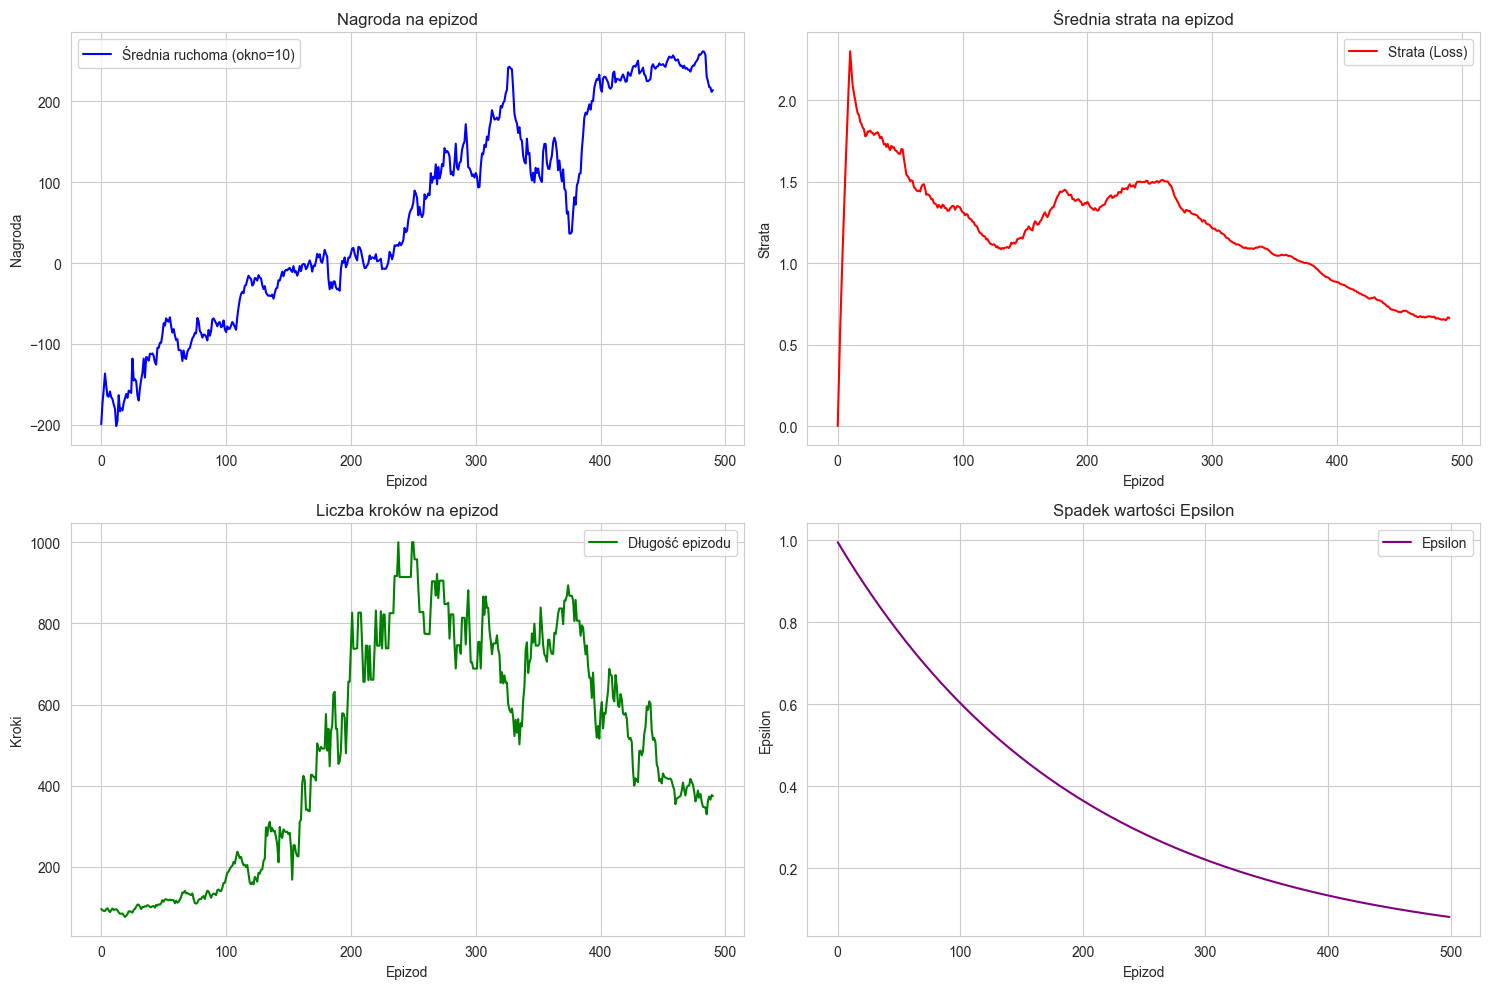

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

window_size = 10
def moving_average(data, w=10):
    if len(data) < w: 
        return data
    return np.convolve(data, np.ones(w) / w, mode='valid')

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Nagrody
axs[0, 0].plot(moving_average(rewards_history, window_size), label=f"\u015arednia ruchoma (okno={window_size})", color='blue')
axs[0, 0].set_title("Nagroda na epizod")
axs[0, 0].set_xlabel("Epizod")
axs[0, 0].set_ylabel("Nagroda")
axs[0, 0].legend()

# 2. Strata (Loss)
axs[0, 1].plot(moving_average(loss_history, window_size), label="Strata (Loss)", color='red')
axs[0, 1].set_title("\u015arednia strata na epizod")
axs[0, 1].set_xlabel("Epizod")
axs[0, 1].set_ylabel("Strata")
axs[0, 1].legend()

# 3. Długość epizodu
axs[1, 0].plot(moving_average(length_history, window_size), label="D\u0142ugo\u015b\u0107 epizodu", color='green')
axs[1, 0].set_title("Liczba krok\u00f3w na epizod")
axs[1, 0].set_xlabel("Epizod")
axs[1, 0].set_ylabel("Kroki")
axs[1, 0].legend()

# 4. Epsilon
axs[1, 1].plot(epsilon_history, label="Epsilon", color='purple')
axs[1, 1].set_title("Spadek warto\u015bci Epsilon")
axs[1, 1].set_xlabel("Epizod")
axs[1, 1].set_ylabel("Epsilon")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

## 8. Wizualizacja lądowania

In [8]:
checkpoint = torch.load('dqn_lunar_lander.pth', map_location=device)
agent.model.load_state_dict(checkpoint['model_state_dict'])

agent.epsilon = 0.0   # tylko nauczona polityka, bez losowych akcji
EPISODES = 3

env = gym.make("LunarLander-v2")
env.action_space.seed(SEED)

for episode in range(EPISODES):
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    done = False
    total_reward = 0
    while not done:
        env.render("human")
        action = agent.act(state)
        result = env.step(action)
        if len(result) == 5:
            state, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            state, reward, done, info = result
        total_reward += reward
    print(f"Epizod {episode + 1}: nagroda {total_reward:.2f}")

env.close()

Epizod 1: nagroda 245.78
Epizod 2: nagroda 216.36
Epizod 3: nagroda 176.58


In [11]:
import json
metrics = {
    'rewards': rewards_history,
    'losses': loss_history,
    'lengths': length_history,
    'epsilons': epsilon_history
}
json.dump(metrics, open('metrics/metrics_history.json', 'w'))